In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости результатов
np.random.seed(42)

In [2]:
# Загрузка данных
train_df = pd.read_csv('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/classification_of_oil_and_gas/classification-of-oil-and-gas/train_oil.csv')
test_df = pd.read_csv('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/classification_of_oil_and_gas/classification-of-oil-and-gas/oil_test.csv')

print("Размер тренировочного набора:", train_df.shape)
print("Размер тестового набора:", test_df.shape)

# Первичный анализ данных
print("\nПервые 5 строк тренировочных данных:")
print(train_df.head())

print("\nИнформация о данных:")
print(train_df.info())

print("\nОписательная статистика числовых признаков:")
print(train_df.describe())

Размер тренировочного набора: (309, 20)
Размер тестового набора: (133, 19)

Первые 5 строк тренировочных данных:
     Field name           Reservoir unit       Country               Region  \
0       ZHIRNOV              MELEKESKIAN        RUSSIA  FORMER SOVIET UNION   
1   LAGOA PARDA  LAGOA PARDA (URUCUTUCA)        BRAZIL        LATIN AMERICA   
2        ABQAIQ                   ARAB D  SAUDI ARABIA          MIDDLE EAST   
3     MURCHISON                    BRENT    UK /NORWAY               EUROPE   
4  WEST PEMBINA   NISKU (PEMBINA L POOL)        CANADA        NORTH AMERICA   

           Basin name        Tectonic regime  Latitude  Longitude  \
0          VOLGA-URAL  COMPRESSION/EVAPORITE   51.0000    44.8042   
1      ESPIRITO SANTO              EXTENSION  -19.6017   -39.8332   
2            THE GULF  COMPRESSION/EVAPORITE   26.0800    49.8100   
3  NORTH SEA NORTHERN              EXTENSION   61.3833     1.7500   
4      WESTERN CANADA            COMPRESSION   53.2287  -115.8008  

## Исследовательский анализ данных (EDA)

Пропущенные значения в тренировочных данных:
Field name                         0
Reservoir unit                     0
Country                           27
Region                            38
Basin name                        38
Tectonic regime                    0
Latitude                          27
Longitude                         30
Operator company                   0
Onshore/Offshore                   0
Hydrocarbon type                   0
Reservoir status                   0
Structural setting                 0
Depth                              0
Reservoir period                   0
Lithology                          0
Thickness (gross average ft)       0
Thickness (net pay average ft)     0
Porosity                           0
Permeability                       0
dtype: int64

Пропущенные значения в тестовых данных:
Field name                         0
Reservoir unit                     0
Country                           13
Region                            16
Basin name   

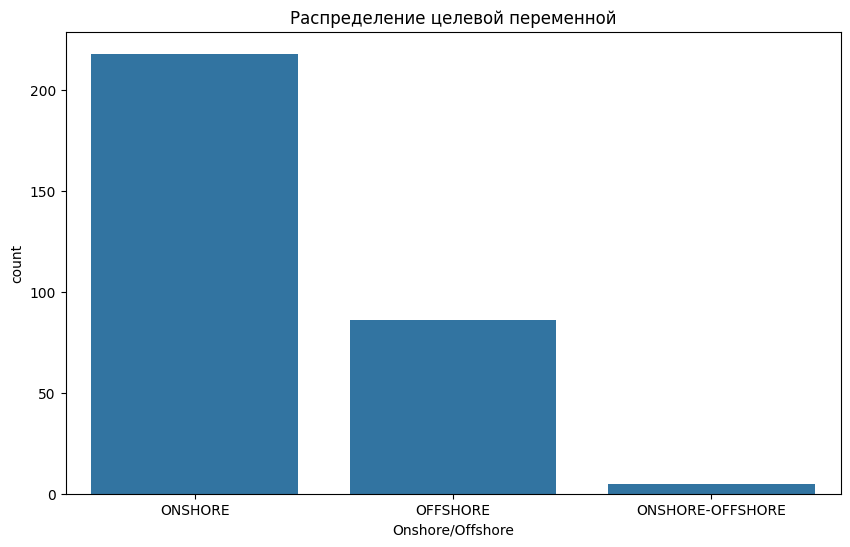


Категориальные признаки: ['Field name', 'Reservoir unit', 'Country', 'Region', 'Basin name', 'Tectonic regime', 'Operator company', 'Onshore/Offshore', 'Hydrocarbon type', 'Reservoir status', 'Structural setting', 'Reservoir period', 'Lithology']

Уникальные значения в Field name: 285

Уникальные значения в Reservoir unit: 258

Уникальные значения в Country: 42

Уникальные значения в Region: 7

Уникальные значения в Basin name: 93


In [5]:
# Проверка пропущенных значений
print("Пропущенные значения в тренировочных данных:")
print(train_df.isnull().sum())

print("\nПропущенные значения в тестовых данных:")
print(test_df.isnull().sum())

# Анализ целевой переменной
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='Onshore/Offshore')
plt.title('Распределение целевой переменной')
plt.show()

# Анализ категориальных признаков
categorical_cols = train_df.select_dtypes(include=['object']).columns
print(f"\nКатегориальные признаки: {list(categorical_cols)}")

for col in categorical_cols[:5]:  # Первые 5 категориальных признаков
    print(f"\nУникальные значения в {col}: {train_df[col].nunique()}")

## Предобработка данных

In [7]:
def preprocess_data(df, is_train=True, label_encoders=None):
    """
    Функция предобработки данных
    """
    df_processed = df.copy()
    
    # Удаление ненужных колонок (название месторождения не несет информации для модели)
    if 'Field name' in df_processed.columns:
        df_processed = df_processed.drop('Field name', axis=1)
    
    # Обработка пропущенных значений
    for col in df_processed.columns:
        if df_processed[col].dtype == 'object':
            # Для категориальных - мода
            df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0] 
                                                         if len(df_processed[col].mode()) > 0 
                                                         else 'Unknown')
        else:
            # Для числовых - медиана
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())
    
    if is_train:
        # Создание энкодеров для тренировочных данных
        label_encoders = {}
        for col in df_processed.select_dtypes(include=['object']).columns:
            if col != 'Onshore or offshore':
                le = LabelEncoder()
                df_processed[col] = le.fit_transform(df_processed[col].astype(str))
                label_encoders[col] = le
    else:
        # Использование существующих энкодеров для тестовых данных
        for col, le in label_encoders.items():
            if col in df_processed.columns:
                # Преобразуем только известные значения, остальные в 'Unknown'
                df_processed[col] = df_processed[col].apply(
                    lambda x: le.transform([x])[0] if x in le.classes_ else -1
                )
    
    return df_processed, label_encoders

# Предобработка тренировочных данных
train_processed, label_encoders = preprocess_data(train_df, is_train=True)

# Разделение на признаки и целевую переменную
X = train_processed.drop('Onshore/Offshore', axis=1)
y = train_processed['Onshore/Offshore']

# Кодирование целевой переменной
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"Размерность признаков: {X.shape}")
print(f"Уникальные значения целевой переменной: {np.unique(y_encoded)}")

Размерность признаков: (309, 18)
Уникальные значения целевой переменной: [0 1 2]


## Feature Engineering и отбор признаков

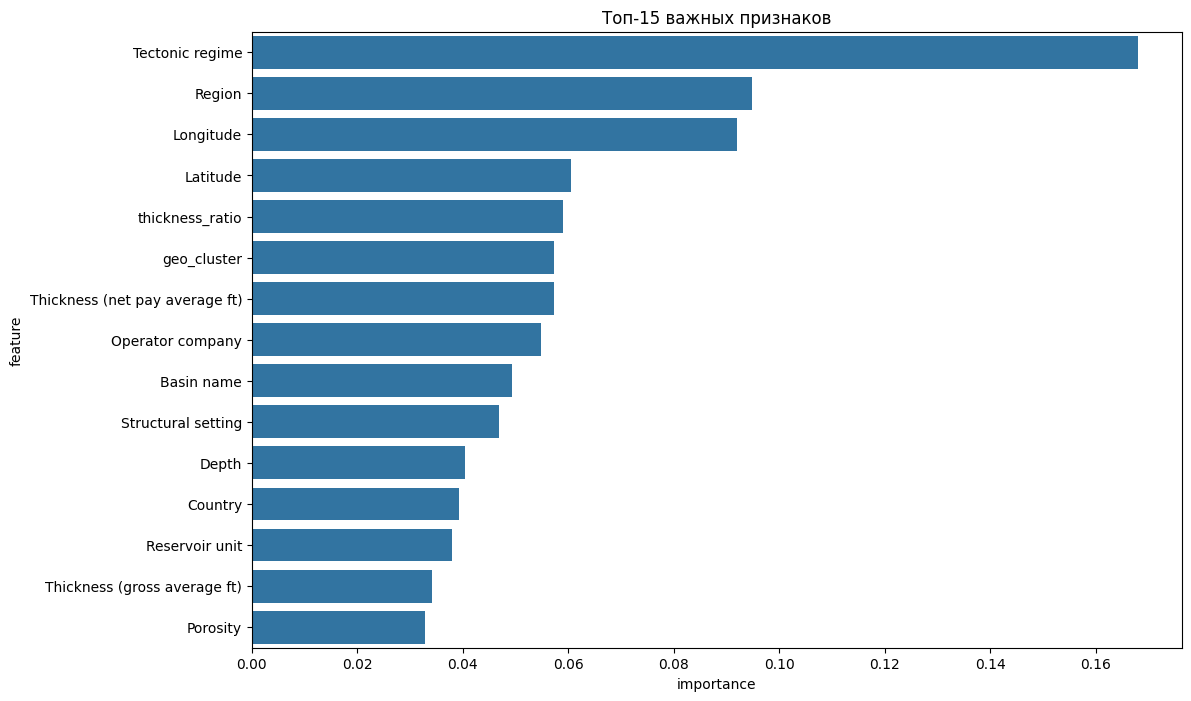

In [8]:
# Создание новых признаков
def create_features(df):
    """
    Создание новых признаков на основе существующих
    """
    df_fe = df.copy()
    
    # Примеры новых признаков:
    # 1. Географический кластер на основе координат
    if 'Latitude' in df.columns and 'Longitude' in df.columns:
        df_fe['geo_cluster'] = (df['Latitude'] // 10 * 100 + df['Longitude'] // 10).astype(int)
    
    # 2. Отношение эффективной толщины к общей
    if 'Thickness (gross average ft)' in df.columns and 'Thickness (net pay average ft)' in df.columns:
        df_fe['thickness_ratio'] = df_fe['Thickness (net pay average ft)'] / (df_fe['Thickness (gross average ft)'] + 1e-6)
    
    # 3. Комбинация глубины и проницаемости
    if 'Depth (top reservoir ft TVD)' in df.columns and 'Permeability (air average mD)' in df.columns:
        df_fe['depth_perm_interaction'] = df_fe['Depth (top reservoir ft TVD)'] * df_fe['Permeability (air average mD)']
    
    return df_fe

# Применение feature engineering
X_fe = create_features(X)

# Анализ важности признаков с помощью RandomForest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_fe, y_encoded)

# Визуализация важности признаков
feature_importance = pd.DataFrame({
    'feature': X_fe.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Топ-15 важных признаков')
plt.show()

# Отбор наиболее важных признаков
selected_features = feature_importance.head(10)['feature'].tolist()
X_selected = X_fe[selected_features]

## Обучение и сравнение нескольких моделей

In [9]:
# Разделение данных на тренировочную и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(
    X_selected, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Список моделей для сравнения
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Обучение и оценка моделей
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    
    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    results[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'model': model
    }
    
    print(f"\n{name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(classification_report(y_val, y_pred))


Logistic Regression:
Accuracy: 0.7097
F1-Score: 0.7081
              precision    recall  f1-score   support

           0       0.47      0.53      0.50        17
           1       0.81      0.80      0.80        44
           2       0.00      0.00      0.00         1

    accuracy                           0.71        62
   macro avg       0.43      0.44      0.43        62
weighted avg       0.71      0.71      0.71        62


Random Forest:
Accuracy: 0.8710
F1-Score: 0.8602
              precision    recall  f1-score   support

           0       0.86      0.71      0.77        17
           1       0.88      0.95      0.91        44
           2       0.00      0.00      0.00         1

    accuracy                           0.87        62
   macro avg       0.58      0.55      0.56        62
weighted avg       0.86      0.87      0.86        62


Gradient Boosting:
Accuracy: 0.8710
F1-Score: 0.8602
              precision    recall  f1-score   support

           0       0.86

## Подбор гиперпараметров для лучшей модели

In [10]:
# Выбор лучшей модели по F1-score
best_model_name = max(results, key=lambda x: results[x]['f1_score'])
best_model = results[best_model_name]['model']
print(f"\nЛучшая модель: {best_model_name}")


Лучшая модель: Random Forest


In [11]:
# Подбор гиперпараметров для Logistic Regression
if best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }
    
    grid_search = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        param_grid,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший F1-score на кросс-валидации: {grid_search.best_score_:.4f}")
    
    best_model = grid_search.best_estimator_

# Подбор гиперпараметров для Random Forest
elif best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    }
    
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший F1-score на кросс-валидации: {grid_search.best_score_:.4f}")
    
    best_model = grid_search.best_estimator_

Лучшие параметры: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Лучший F1-score на кросс-валидации: 0.8800


## Предсказание на тестовых данных

In [15]:
# Предобработка тестовых данных
test_processed, _ = preprocess_data(test_df, is_train=False, label_encoders=label_encoders)
test_fe = create_features(test_processed)

# Использование только отобранных признаков
X_test = test_fe[selected_features].reindex(columns=selected_features, fill_value=0)

# Масштабирование тестовых данных
X_test_scaled = scaler.transform(X_test)

# Предсказание
test_predictions = best_model.predict(X_test_scaled)
test_predictions_decoded = le_target.inverse_transform(test_predictions)

# Создание submission файла
submission = pd.DataFrame({
    # 'Field name': test_df['Field name'],
    'Onshore/Offshore': test_predictions_decoded
})

# Сохранение результатов
submission.to_csv('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/classification_of_oil_and_gas/classification-of-oil-and-gas/submission.csv', index=True)
print("\nФайл submission.csv сохранен")


Файл submission.csv сохранен


## Визуализация результатов

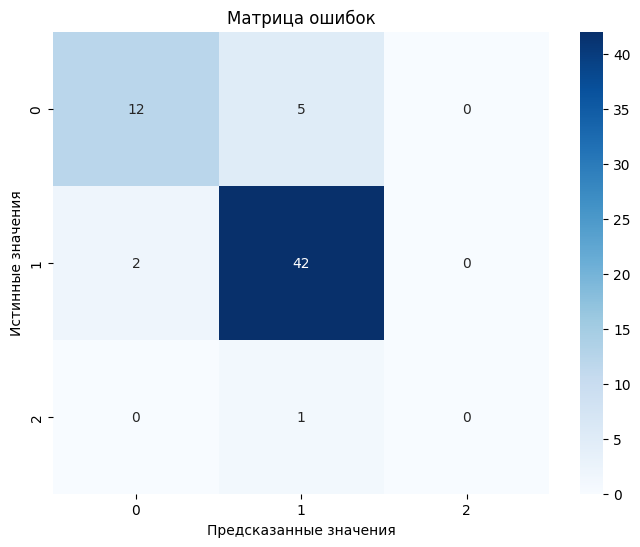

<Figure size 1000x600 with 0 Axes>

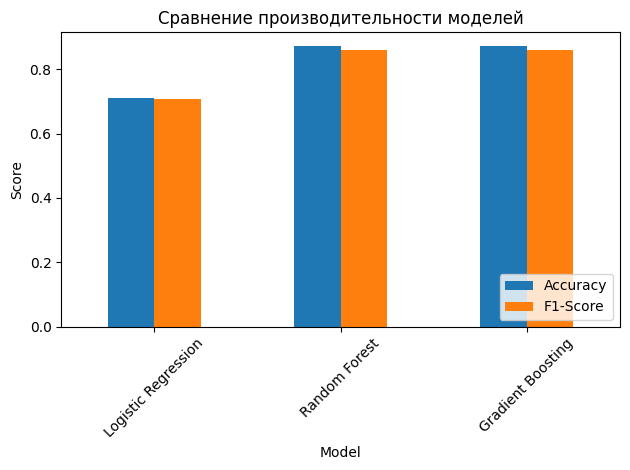

In [13]:
# Матрица ошибок для валидационной выборки
y_val_pred = best_model.predict(X_val_scaled)
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

# Сравнение производительности моделей
comparison_df = pd.DataFrame([
    {'Model': name, 'Accuracy': results[name]['accuracy'], 'F1-Score': results[name]['f1_score']}
    for name in results
])

plt.figure(figsize=(10, 6))
comparison_df.set_index('Model')[['Accuracy', 'F1-Score']].plot(kind='bar')
plt.title('Сравнение производительности моделей')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Kaggle

/masters_degree_Roshchin_M25-555/ML/classification_of_oil_and_gas/classification-of-oil-and-gas/Screenshot 2025-12-16 at 15.57.40.png